In [10]:
# =============================================================================
# Neural Network from First Principles — Math, Code, and XOR
#
# A complete mathematical and programming walkthrough of a neural network
# built from scratch with Python and NumPy.
#
# Rather than relying on a deep-learning framework, this notebook derives and
# implements the core mechanics directly: matrix-based forward propagation,
# activation functions, loss calculation, gradient flow, backpropagation, and
# parameter updates.
#
# The walkthrough connects every mathematical expression to the code that
# executes it, then brings the pieces together in a working neural network that
# learns the nonlinear XOR function.
#
# Attribution:
# This notebook is an educational adaptation and expanded walkthrough of the
# neural-network implementation and teaching sequence created by
# The Independent Code. Credit for the original implementation, mathematical
# presentation, and corresponding instructional material belongs to its author.
#
# Original repository:
# https://github.com/TheIndependentCode/Neural-Network
#
# Corresponding video walkthrough:
# https://www.youtube.com/watch?v=pauPCy_s0Ok&t=1325s
#
# The material presented here has been reorganized, annotated, and expanded to
# connect each mathematical step with its Python implementation and its role in
# the complete training flow.
#
# The journey:
#   1. Define the responsibilities of a neural-network layer
#   2. Derive and implement the Dense-layer forward equation: Y = WX + B
#   3. Derive the Dense-layer gradients for W, B, and X
#   4. Apply the chain rule through activation functions
#   5. Implement Tanh and Sigmoid together with their derivatives
#   6. Define Mean Squared Error and its prediction gradient
#   7. Connect layers into a complete forward pass
#   8. Propagate the loss gradient backward through the network
#   9. Update trainable parameters using gradient descent
#  10. Represent the XOR truth table as neural-network tensors
#  11. Construct and train a nonlinear XOR network
#  12. Inspect predictions, classification accuracy, and training loss
#  13. Visualize the continuous function learned between the XOR samples
#  14. Interpret the learned three-dimensional decision surface
#
# No neural-network or automatic-differentiation framework is used.
# Every forward equation, derivative, gradient, and parameter update is
# implemented explicitly so the relationship between the mathematics and
# the Python code remains visible throughout the notebook.
# =============================================================================

In [11]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

## The Neural-Network Learning Loop

Before implementing the individual layers, it helps to see the complete learning cycle. An input moves forward through the network to produce a prediction, the prediction is compared with the expected output to calculate an error, and that error is propagated backward to determine how each trainable parameter should change. Repeating this process gradually reduces the loss.

![Machine-learning training loop: forward pass, error calculation, gradient-descent update, and repetition](images/training_loop_overview.jpg)

*The four recurring stages of training: compute the network output, measure the error, update the parameters using gradient descent, and repeat.*

At the layer level, the same process becomes two opposite flows: activations move forward through the network, while error gradients move backward during backpropagation.

![Forward activations and backward error gradients flowing through a sequence of neural-network layers](images/forward_backward_signal_flow.png)

In [12]:
# ============================================================
# Base Layer
# ============================================================


class Layer:
    """
    Base class for every neural-network layer.

    Each layer must implement:

    forward(input):
        Receives the input of the layer and returns its output.

    backward(output_gradient, learning_rate):
        Receives the gradient of the loss with respect to the layer's output,
        calculates the gradient with respect to the layer's input, and updates
        trainable parameters when the layer contains any.
    """

    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        raise NotImplementedError(
            "Every layer must implement its own forward() method."
        )

    def backward(self, output_gradient, learning_rate):
        raise NotImplementedError(
            "Every layer must implement its own backward() method."
        )

## Dense Layers: From the Forward Equation to Backpropagation

A Dense layer connects every input value to every output neuron. During the forward pass, each output is a weighted sum of all inputs plus its own bias. Writing the neuron-by-neuron equations as a matrix operation gives the compact expression `Y = WX + B`, which is exactly what the `forward` method below computes.

### 1. Forward propagation and the weight gradient

![Dense-layer connections, matrix-form forward propagation, and derivation of the weight gradient](images/dense_layer_forward_and_weight_gradient.jpg)

The first diagram moves from individual neuron equations to their matrix form. It then applies the chain rule to each weight. A weight affects only the output neuron to which it is connected, so collecting all individual derivatives produces the matrix result `dE/dW = (dE/dY) Xᵀ`. The outer product between the incoming output gradient and the transposed input has the same shape as `W`.

### 2. The gradient with respect to the input

![Derivation of the Dense-layer input gradient](images/dense_layer_input_gradient.jpg)

Backpropagation must also tell the preceding layer how much each input contributed to the final error. Every input influences every output through a different weight. Summing those paths gives `dE/dX = Wᵀ(dE/dY)`. This is the gradient returned by `backward`, allowing the chain rule to continue through the rest of the network. It must be calculated before the weights are updated so that it uses the same `W` that produced the forward output.

### 3. The gradient with respect to the bias

![Derivation of the Dense-layer bias gradient](images/dense_layer_bias_gradient.jpg)

Each bias is added directly to one output, so its local derivative is `1`. The bias gradient is therefore the incoming output gradient itself: `dE/dB = dE/dY`. Once the weight and bias gradients are known, gradient descent can move both parameters in the direction that reduces the error.

Together, the Dense layer uses four equations:

```text
Forward:          Y     = W X + B
Weight gradient: dE/dW = (dE/dY) Xᵀ
Input gradient:  dE/dX = Wᵀ (dE/dY)
Bias gradient:   dE/dB = dE/dY
```

The following implementation translates these equations directly into NumPy operations.

In [13]:
# ============================================================
# Dense / Fully Connected Layer
# ============================================================


class Dense(Layer):
    """
    A fully connected neural-network layer.

    If the input has shape:

        (input_size, 1)

    and the layer contains output_size neurons, then:

        weights shape = (output_size, input_size)
        bias shape    = (output_size, 1)
        output shape  = (output_size, 1)

    Forward propagation:

        Y = W @ X + B

    Backpropagation:

        dE/dW = dE/dY @ X.T
        dE/dB = dE/dY
        dE/dX = W.T @ dE/dY
    """

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_size = input_size
        self.output_size = output_size

        # Randomly initialize the trainable parameters.
        #
        # weights:
        # Each row contains the weights of one neuron.
        #
        # bias:
        # Each output neuron receives one bias value.
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        """
        Calculate the output of the layer.

        Y = W @ X + B
        """

        self.input = input
        self.output = np.dot(self.weights, self.input) + self.bias
        return self.output

    def backward(self, output_gradient, learning_rate):
        """
        Perform backpropagation through the Dense layer.

        output_gradient represents:

            dE/dY

        where:
            E = loss/error
            Y = output of this layer
        """

        # Gradient of the loss with respect to the weights:
        #
        # dE/dW = dE/dY @ X.T
        weights_gradient = np.dot(output_gradient, self.input.T)

        # Gradient of the loss with respect to the input:
        #
        # dE/dX = W.T @ dE/dY
        #
        # This must be calculated before updating the weights so that
        # the gradient uses the same weights that were used during the
        # corresponding forward pass.
        input_gradient = np.dot(self.weights.T, output_gradient)

        # Gradient-descent parameter update:
        #
        # new_parameter =
        #     old_parameter - learning_rate * parameter_gradient
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        # Return the input gradient so that the previous layer can continue
        # the backpropagation process.
        return input_gradient

## Activation Layers: Introducing Nonlinearity

A Dense layer can mix and transform features, but its operation is still linear. Stacking Dense layers without nonlinear activation functions would collapse into another linear transformation, preventing the network from learning patterns such as XOR. An activation layer solves this by applying a function `f` independently to every element of its input.

![Element-wise activation-layer forward propagation and chain-rule backpropagation](images/activation_layer_forward_and_backward.jpg)

During the forward pass, each input element is transformed independently, giving `Y = f(X)`. During backpropagation, the incoming gradient `dE/dY` is multiplied element by element by the local derivative `f′(X)`. The result is `dE/dX = (dE/dY) ⊙ f′(X)`, where `⊙` denotes element-wise multiplication rather than matrix multiplication.

The generic implementation below receives both `function` and `function_derivative`, allowing the same layer logic to support Tanh, Sigmoid, and other activation functions. Because an activation layer has no trainable weights or biases, it propagates the gradient but does not update parameters.

In [14]:
# ============================================================
# Generic Activation Layer
# ============================================================


class Activation(Layer):
    """
    Generic activation layer.

    An Activation object receives:

        function:
            The activation function f(x).

        function_derivative:
            The derivative f'(x).

    Forward propagation:

        Y = f(X)

    Backpropagation:

        dE/dX = dE/dY ⊙ f'(X)

    where ⊙ is element-wise multiplication.
    """

    def __init__(self, function, function_derivative):
        super().__init__()
        self.function = function
        self.function_derivative = function_derivative

    def forward(self, input):
        """Apply the activation function element by element."""

        self.input = input
        self.output = self.function(self.input)
        return self.output

    def backward(self, output_gradient, learning_rate):
        """
        Apply the chain rule:

            dE/dX = dE/dY ⊙ f'(X)

        Activation layers do not contain trainable parameters, so the
        learning_rate argument is accepted for API consistency but is
        not used.
        """

        input_gradient = np.multiply(
            output_gradient,
            self.function_derivative(self.input),
        )

        return input_gradient

## Tanh and Its Derivative

The hyperbolic tangent activation maps any real input to the interval `(-1, 1)`. Its zero-centered S-shape introduces the nonlinearity that allows the network to represent relationships such as XOR.

![The Tanh activation function and its derivative](images/tanh_and_derivative.png)

The **blue curve** is the activation function `tanh(x)`. The **green curve is the derivative of the blue curve**, calculated as `1 - tanh²(x)`. Near `x = 0`, the blue curve is steep and the green derivative reaches its maximum value of `1`, so gradients can pass through effectively. For large positive or negative inputs, the blue curve saturates near `1` or `-1`, while the green derivative approaches `0`; in those regions, backpropagated gradients become much smaller.

The `Tanh` class below supplies both expressions to the generic `Activation` layer: `np.tanh(x)` for the forward pass and `1 - np.tanh(x) ** 2` for backpropagation.

In [15]:
# ============================================================
# Tanh Activation
# ============================================================


class Tanh(Activation):
    """
    Hyperbolic-tangent activation.

    Function:

        tanh(x)

    Derivative:

        1 - tanh(x)^2

    Output range:

        (-1, 1)
    """

    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_derivative(x):
            return 1 - np.tanh(x) ** 2

        super().__init__(
            function=tanh,
            function_derivative=tanh_derivative,
        )

## Measuring the Prediction Error

Once the network has produced a prediction, we need a single number that tells us how far that prediction is from the expected output. Mean Squared Error (MSE) compares every predicted value in $Y$ with its corresponding target value in $Y^*$, squares those differences, and averages them.

![Mean Squared Error and its derivative with respect to the prediction vector](images/mean_squared_error_and_derivative.jpg)

Squaring keeps positive and negative errors from cancelling each other out, while also giving larger mistakes more influence. The result is the loss value that the network will try to minimize during training.

The derivative shown in the image, $\frac{\partial E}{\partial Y} = \frac{2}{n}(Y - Y^*)$, tells us how the loss changes when the network's prediction changes. This is the first gradient passed into the final layer, from which backpropagation works backward through the rest of the network. In the code below, `mse` computes the loss and `mse_derivative` computes exactly this starting gradient.

In [16]:
# ============================================================
# Loss Function — Mean Squared Error
# ============================================================


def mse(y_true, y_pred):
    """
    Mean Squared Error.

    Formula:

        MSE = mean((y_true - y_pred)^2)
    """

    return np.mean(np.power(y_true - y_pred, 2))


def mse_derivative(y_true, y_pred):
    """
    Derivative of Mean Squared Error with respect to y_pred.

    If:

        E = mean((y_true - y_pred)^2)

    then:

        dE/dy_pred = 2 * (y_pred - y_true) / number_of_values
    """

    return 2 * (y_pred - y_true) / np.size(y_true)


# Alias matching the name used by the separated implementation.
mse_prime = mse_derivative

In [17]:
# ============================================================
# Prediction / Forward Propagation
# ============================================================


def predict(network, input):
    """
    Pass an input through every layer in the network.

    The output of one layer becomes the input of the next layer.
    """

    output = input

    for layer in network:
        output = layer.forward(output)

    return output


# ============================================================
# Training
# ============================================================


def train(
    network,
    loss,
    loss_derivative,
    X_train,
    Y_train,
    epochs=10_000,
    learning_rate=0.01,
    verbose=True,
    print_every=10,
):
    """
    Train the neural network using sample-by-sample gradient descent.

    For every epoch:

        1. Send every training sample through the network.
        2. Calculate its loss.
        3. Calculate the derivative of the loss.
        4. Send the gradient backward through all layers.
        5. Update the trainable parameters.
        6. Calculate the average epoch loss.

    Returns:
        A NumPy array containing the average loss from every epoch.
    """

    loss_history = []

    for epoch in range(epochs):
        epoch_error = 0.0

        for x, y in zip(X_train, Y_train):

            # ------------------------------------------------
            # Forward propagation
            # ------------------------------------------------

            output = predict(network, x)

            # ------------------------------------------------
            # Calculate loss
            # ------------------------------------------------

            epoch_error += loss(y, output)

            # ------------------------------------------------
            # Initial loss gradient
            # ------------------------------------------------

            gradient = loss_derivative(y, output)

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------
            #
            # Gradients must flow in the reverse order:
            #
            # output layer -> ... -> input layer
            # ------------------------------------------------

            for layer in reversed(network):
                gradient = layer.backward(gradient, learning_rate)

        # Average error across the training samples.
        epoch_error /= len(X_train)
        loss_history.append(epoch_error)

        if (
            verbose
            and print_every is not None
            and epoch % print_every == 0
        ):
            print(
                f"Epoch {epoch + 1:4d}/{epochs}, "
                f"loss={epoch_error:.10f}"
            )

    return np.array(loss_history)

## The XOR Learning Problem

XOR, or *exclusive OR*, returns 1 when the two inputs are different and 0 when they are the same. Its four possible input combinations form the complete dataset shown on the left.

![XOR truth table and neural-network architecture](images/xor_truth_table_and_network.png)

Although the truth table is tiny, XOR is an important neural-network example because its classes cannot be separated by a single straight line. A hidden layer is therefore needed to transform the two inputs into a representation from which the output can be learned.

The code below converts the four rows of the truth table into column vectors. Each sample contains two input values, $x_1$ and $x_2$, and one expected output, $y_1$. These samples will be passed through the network repeatedly during training.

In [18]:
# ============================================================
# XOR Dataset
# ============================================================

# XOR truth table:
#
#  x1  x2  |  y
# ----------------
#   0   0   |  0
#   0   1   |  1
#   1   0   |  1
#   1   1   |  0
#
# Every input is represented as a two-dimensional column vector:
#
#     [[x1],
#      [x2]]
#
# Therefore, X has shape:
#
#     (4 samples, 2 features, 1 column)
#
# Y has shape:
#
#     (4 samples, 1 output, 1 column)


X = np.reshape(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ],
    (4, 2, 1),
)

Y = np.reshape(
    [
        [0],
        [1],
        [1],
        [0],
    ],
    (4, 1, 1),
)

In [19]:
# ============================================================
# Network Architecture
# ============================================================

# Architecture:
#
# Input:
#     2 values: x1 and x2
#
# Hidden layer:
#     Dense(2, 3)
#     Tanh
#
# Output layer:
#     Dense(3, 1)
#     Tanh
#
# Flow:
#
#     [x1, x2]
#         ↓
#     Dense: 2 → 3
#         ↓
#       Tanh
#         ↓
#     Dense: 3 → 1
#         ↓
#       Tanh
#         ↓
#     prediction


network = [
    Dense(input_size=2, output_size=3),
    Tanh(),
    Dense(input_size=3, output_size=1),
    Tanh(),
]


# ============================================================
# Train the XOR Network
# ============================================================


loss_history = train(
    network=network,
    loss=mse,
    loss_derivative=mse_derivative,
    X_train=X,
    Y_train=Y,
    epochs=1000,
    learning_rate=0.1,
    verbose=True,
    print_every=10,
)

Epoch    1/1000, loss=0.7507937726
Epoch   11/1000, loss=0.2613034015
Epoch   21/1000, loss=0.2505990242
Epoch   31/1000, loss=0.2481717288
Epoch   41/1000, loss=0.2467872807
Epoch   51/1000, loss=0.2455450402
Epoch   61/1000, loss=0.2440974374
Epoch   71/1000, loss=0.2421225490
Epoch   81/1000, loss=0.2391322240
Epoch   91/1000, loss=0.2343795394
Epoch  101/1000, loss=0.2277307524
Epoch  111/1000, loss=0.2226170438
Epoch  121/1000, loss=0.2203688509
Epoch  131/1000, loss=0.2175495846
Epoch  141/1000, loss=0.2141965592
Epoch  151/1000, loss=0.2108899150
Epoch  161/1000, loss=0.2077481667
Epoch  171/1000, loss=0.2047398787
Epoch  181/1000, loss=0.2017753606
Epoch  191/1000, loss=0.1986824357
Epoch  201/1000, loss=0.1951257322
Epoch  211/1000, loss=0.1903168041
Epoch  221/1000, loss=0.1817272787
Epoch  231/1000, loss=0.1579035873
Epoch  241/1000, loss=0.0872188138
Epoch  251/1000, loss=0.0327916168
Epoch  261/1000, loss=0.0163673358
Epoch  271/1000, loss=0.0102690451
Epoch  281/1000, los

In [20]:
# ============================================================
# Display XOR Predictions
# ============================================================


print("\n" + "=" * 68)
print("XOR PREDICTIONS")
print("=" * 68)

prediction_rows = []

for x, expected in zip(X, Y):
    prediction = predict(network, x)

    x1 = int(x[0, 0])
    x2 = int(x[1, 0])
    expected_value = float(expected[0, 0])
    predicted_value = float(prediction[0, 0])

    # Tanh outputs may be slightly below zero or above one.
    # For the XOR classification decision, 0.5 is used as the threshold.
    predicted_class = int(predicted_value >= 0.5)

    prediction_rows.append(
        {
            "x1": x1,
            "x2": x2,
            "expected": int(expected_value),
            "raw_prediction": predicted_value,
            "predicted_class": predicted_class,
        }
    )

    print(
        f"Input: ({x1}, {x2}) | "
        f"Expected: {int(expected_value)} | "
        f"Raw prediction: {predicted_value:.6f} | "
        f"Predicted class: {predicted_class}"
    )


XOR PREDICTIONS
Input: (0, 0) | Expected: 0 | Raw prediction: 0.000593 | Predicted class: 0
Input: (0, 1) | Expected: 1 | Raw prediction: 0.981026 | Predicted class: 1
Input: (1, 0) | Expected: 1 | Raw prediction: 0.975497 | Predicted class: 1
Input: (1, 1) | Expected: 0 | Raw prediction: -0.001038 | Predicted class: 0


In [21]:
# ============================================================
# Calculate XOR Classification Accuracy
# ============================================================


correct_predictions = sum(
    row["predicted_class"] == row["expected"]
    for row in prediction_rows
)

accuracy = correct_predictions / len(prediction_rows)

print("-" * 68)
print(f"Accuracy: {correct_predictions}/{len(prediction_rows)}")
print(f"Accuracy percentage: {accuracy * 100:.2f}%")
print(f"Final training loss: {loss_history[-1]:.10f}")
print("=" * 68)

--------------------------------------------------------------------
Accuracy: 4/4
Accuracy percentage: 100.00%
Final training loss: 0.0002409098


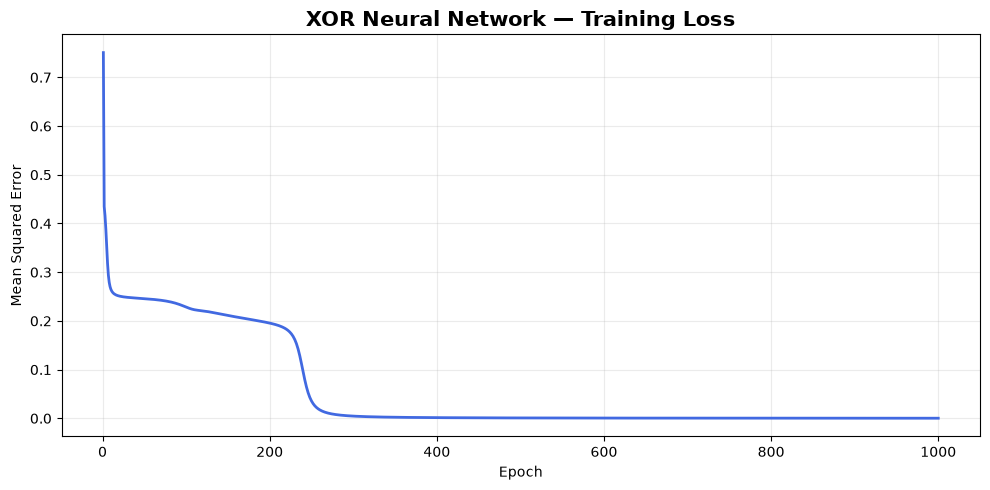

In [22]:
# ============================================================
# Plot 1 — Training Loss
# ============================================================


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    np.arange(1, len(loss_history) + 1),
    loss_history,
    color="royalblue",
    linewidth=2,
)

ax.set_title(
    "XOR Neural Network — Training Loss",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Mapping the Learned XOR Surface

After verifying the network's predictions at the four XOR inputs, we can examine what it has learned across the entire two-dimensional input space. For any point $p = (x_1, x_2)$, a forward pass produces a value $z = \operatorname{network}(p)$.

![Evaluating the trained XOR network across the input space](images/xor_surface_sampling_grid.png)

The grid illustrates the next step: generate many points between 0 and 1, evaluate the trained network at every point, and plot each predicted value $z$ above its corresponding $(x_1, x_2)$ position. Together, those predictions reveal the nonlinear surface learned by the network.

The code below creates that dense input grid. Increasing its resolution produces a smoother surface, but also requires more forward passes through the network.

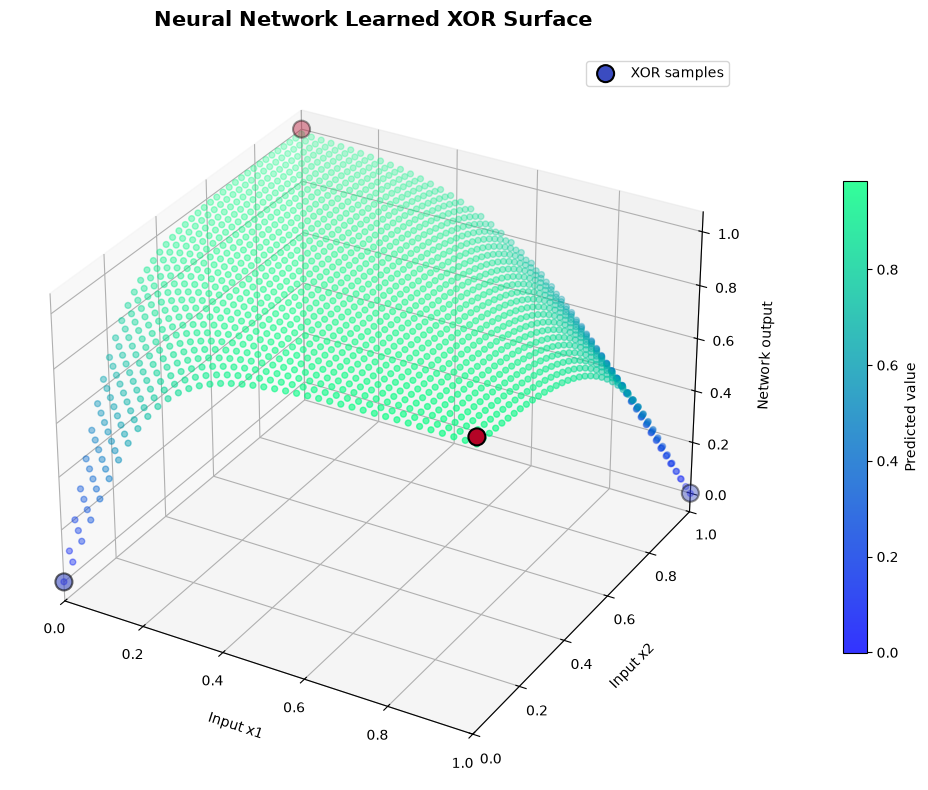

In [23]:
# ============================================================
# Create Points for the Learned XOR Surface
# ============================================================

# Create a two-dimensional grid between 0 and 1.
#
# Increasing grid_resolution produces a smoother visualization but requires
# more forward passes through the network.


grid_resolution = 40

x1_values = np.linspace(0, 1, grid_resolution)
x2_values = np.linspace(0, 1, grid_resolution)

surface_points = []

for x1 in x1_values:
    for x2 in x2_values:
        model_input = np.array(
            [
                [x1],
                [x2],
            ]
        )

        prediction = predict(network, model_input)
        predicted_value = float(prediction[0, 0])

        surface_points.append(
            [
                x1,
                x2,
                predicted_value,
            ]
        )

surface_points = np.array(surface_points)


# ============================================================
# Plot 2 — 3D Learned XOR Surface
# ============================================================


fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

surface_plot = ax.scatter(
    surface_points[:, 0],
    surface_points[:, 1],
    surface_points[:, 2],
    c=surface_points[:, 2],
    cmap="winter",
    s=18,
    alpha=0.8,
)

# Add the four original XOR data points on top of the learned surface.

original_x1 = X[:, 0, 0]
original_x2 = X[:, 1, 0]
original_y = Y[:, 0, 0]

ax.scatter(
    original_x1,
    original_x2,
    original_y,
    c=original_y,
    cmap="coolwarm",
    edgecolors="black",
    linewidths=1.5,
    s=150,
    marker="o",
    label="XOR samples",
)

ax.set_title(
    "Neural Network Learned XOR Surface",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.set_xlabel("Input x1", labelpad=10)
ax.set_ylabel("Input x2", labelpad=10)
ax.set_zlabel("Network output", labelpad=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.colorbar(
    surface_plot,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label="Predicted value",
)

ax.legend()
plt.tight_layout()
plt.show()